# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import recall_score
import plotly.figure_factory as ff

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
#seu código aqui
#Carregando as bases
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [3]:
X_test

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25.0,5500000.0,0,1,1,0,1,0,0,0
1,48.0,8750000.0,1,0,0,0,0,1,0,0
2,26.0,5500000.0,1,0,0,0,1,0,0,0
3,39.0,6250000.0,2,0,0,0,1,0,0,0
4,35.0,9000000.0,1,0,0,0,0,1,0,0
5,25.0,5500000.0,0,1,1,0,1,0,0,0
6,48.0,8250000.0,1,0,0,0,0,1,0,0
7,48.0,8250000.0,1,0,0,0,0,1,0,0
8,36.0,9500000.0,2,0,0,0,0,0,0,1
9,37.0,9500000.0,1,0,0,0,0,0,1,0


In [4]:
y_test

,Credit Score
0,Average
1,High
2,Average
3,High
4,High
5,Average
6,High
7,High
8,High
9,High


In [5]:
y_train

,Credit Score
0,Average
1,Low
2,Average
3,Average
4,Average
...,...
118,High
119,Average
120,High
121,High


In [6]:
X_train

,Age,Income,Number of Children,Marital Status_Single,Home Ownership_Rented,Gender_Male,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26.0,4500000.0,0,1,1,0,0,0,0,0
1,29.0,2750000.0,0,1,1,0,0,0,1,0
2,25.0,6250000.0,0,1,1,0,1,0,0,0
3,29.0,6800000.0,2,0,0,0,0,1,0,0
4,31.0,6500000.0,0,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
118,46.0,9750000.0,1,0,0,0,0,0,1,0
119,32.0,5750000.0,0,1,1,1,0,0,0,0
120,37.0,7000000.0,2,0,0,0,1,0,0,0
121,37.0,8500000.0,1,0,0,0,0,1,0,0


In [7]:
train_balance = y_train.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test.value_counts()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
Credit Score
High            84
Average         30
Low              9
Name: count, dtype: int64

Balanceamento em y_test:
Credit Score
High            29
Average          6
Low              6
Name: count, dtype: int64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [8]:
#seu código aqui
naive_credito = GaussianNB()

naive_credito.fit(X_train,y_train)

C:\Users\Supervisor\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,priors,None
,var_smoothing,1e-09


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

In [9]:
#seu código aqui
# Acuracia
y_pred_train = naive_credito.predict(X_train)
# Calcular a acurácia
accuracy = accuracy_score(y_train, y_pred_train)
print("Acurácia:", accuracy)

Acurácia: 0.9186991869918699


In [10]:
# Recall
recall = recall_score(y_train, y_pred_train, average='macro')
print("Recall:", recall)

Recall: 0.9317460317460317


In [13]:
previsoes = naive_credito.predict(X_test)

relatorio_teste = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio_teste)

Relatório de Classificação:
              precision    recall  f1-score   support

     Average       0.75      1.00      0.86         6
        High       1.00      0.93      0.96        29
         Low       1.00      1.00      1.00         6

    accuracy                           0.95        41
   macro avg       0.92      0.98      0.94        41
weighted avg       0.96      0.95      0.95        41



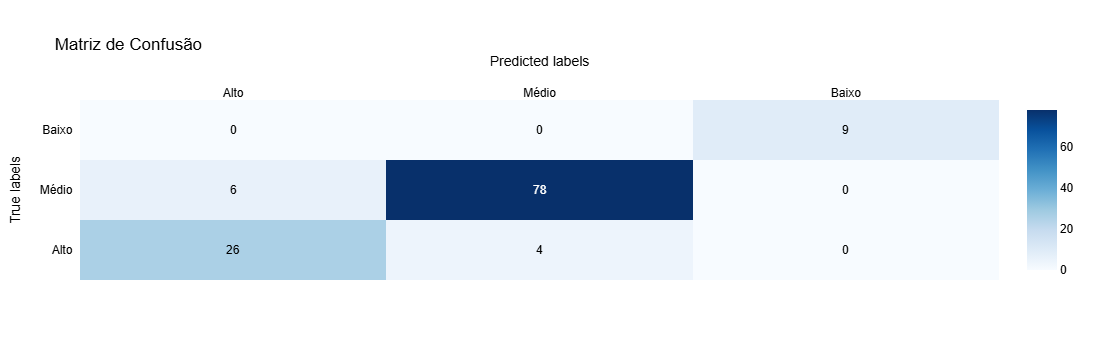

In [11]:
# Matriz de confusão

conf_matrix = confusion_matrix(y_train, y_pred_train)

# Definindo  nomes de classes
class_names = ['Alto','Médio','Baixo']

# Plotando a matriz de confusão com Plotly
fig = ff.create_annotated_heatmap(
    z=conf_matrix,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)
fig.update_layout(
    title='Matriz de Confusão',
    xaxis_title='Predicted labels',
    yaxis_title='True labels',
    font=dict(
        family='Arial',
        size=12,
        color='black'
    )
)

In [12]:
conf_matrix = confusion_matrix(y_train, y_pred_train)

conf_matrix

array([[26,  4,  0],
       [ 6, 78,  0],
       [ 0,  0,  9]])

**De acordo com as métricas de acurácia e recall, sendo recall com aproximadamente 0.91 e acuracia 0.95 o nosso modelo consegue prever com grande exatidão os proximos scores de crédito, mostrando que conseguiu generalizar bem**

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [13]:
#seu código aqui
y_pred_test = naive_credito.predict(X_test)

In [14]:
# Medindo a acuracia e o recall dos nossos dados de teste
y_pred_test = naive_credito.predict(X_test)
# Calcular a acurácia
accuracy = accuracy_score(y_test, y_pred_test)
print("Acurácia:", accuracy)

recall = recall_score(y_test, y_pred_test, average='macro')
print("Recall:", recall)

Acurácia: 0.9512195121951219
Recall: 0.9770114942528735


In [ ]:
relatorio_teste = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio_teste)

**Os desempenhos na base de testes também foram bastante satisfátorios com o recall e a acurácia apresentando valores ainda maiores do que nos dados de treino, sendo Acurácia 0,95 e Recall 0,97,Isso indica que o modelo generaliza bem e que não houve overfitting**

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!